У цій ячейці ми підключаємо основні інструменти для роботи з даними (Pandas, Numpy), наукові обчислення (Scipy) та модуль для вимірювання часу виконання коду.

In [39]:
import pandas as pd
import numpy as np
import timeit
from scipy.stats import pearsonr, spearmanr

Ми зчитуємо дані з файлу household_power_consumption.txt. Оскільки файл великий, використовуємо low_memory=False та вказуємо, що символи ? слід інтерпретувати як пропущені значення (NaN).

In [40]:
df = pd.read_csv('household_power_consumption.txt', sep=';', 
                 low_memory=False, na_values=['?'])
display(df)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


Ця функція об'єднує дату та час у єдиний формат datetime, конвертує всі показники у числовий формат та заповнює пропуски за допомогою лінійної інтерполяції.

In [41]:


def clean_household_data(df):
   
    
    df_clean = df.copy()

   
    df_clean['dt'] = pd.to_datetime(df_clean['Date'] + ' ' + df_clean['Time'], 
                                    dayfirst=True)
    df_clean.drop(['Date', 'Time'], axis=1, inplace=True)
    df_clean.set_index('dt', inplace=True)

   
    cols = df_clean.columns
    df_clean[cols] = df_clean[cols].apply(pd.to_numeric, errors='coerce')

    cols_fix_type = ['Global_active_power', 'Global_reactive_power', 'Voltage','Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    df_clean[cols_fix_type]=df_clean[cols_fix_type].interpolate(method='linear')
    
   
    if df_clean.isnull().values.any():
        df_clean.fillna(df_clean.median(), inplace=True)

    return df_clean

Перевірка результатів очищення та структура обробленого датасету

In [42]:
df_cleaned = clean_household_data(df)
print(df_cleaned.info())
display(df_cleaned.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Вибірка записів, у яких загальна активна споживана потужність перевищує 5 кВт

In [43]:
def get_high_power(data):
    return data[data['Global_active_power'] > 5]


execution_time = timeit.timeit(lambda: get_high_power(df_cleaned), number=1)
result_4_1 = get_high_power(df_cleaned)

print(f"Час виконання: {execution_time:.5f} секунд")
print(f"Кількість знайдених записів: {len(result_4_1)}")
display(result_4_1.head())

Час виконання: 0.00622 секунд
Кількість знайдених записів: 17550


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:35:00,5.412,0.470,232.78,23.2,0.0,1.0,17.0
2006-12-16 17:36:00,5.224,0.478,232.99,22.4,0.0,1.0,16.0


Вибірка за силою струму (19-20 А) та порівняння споживання приладів

In [44]:
def get_specific_intensity(data):
    return data[(data['Global_intensity'] >= 19) & 
                (data['Global_intensity'] <= 20) & 
                (data['Sub_metering_2'] > data['Sub_metering_3'])]


execution_time = timeit.timeit(lambda: get_specific_intensity(df_cleaned), number=1)
result_4_2 = get_specific_intensity(df_cleaned)

print(f"Час виконання: {execution_time:.5f} секунд")
display(result_4_2.head())

Час виконання: 0.01409 секунд


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 18:09:00,4.464,0.136,234.66,19.0,0.0,37.0,16.0
2006-12-17 01:04:00,4.582,0.258,238.08,19.6,0.0,13.0,0.0
2006-12-17 01:08:00,4.618,0.104,239.61,19.6,0.0,27.0,0.0
2006-12-17 01:19:00,4.636,0.140,237.37,19.4,0.0,36.0,0.0
2006-12-17 01:20:00,4.634,0.152,237.17,19.4,0.0,35.0,0.0


Випадкова вибірка 500 000 записів та розрахунок середніх значень

In [45]:
def get_random_means(data):
    sample = data.sample(n=500000, replace=False)
    return sample[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()


execution_time = timeit.timeit(lambda: get_random_means(df_cleaned), number=1)
result_4_3 = get_random_means(df_cleaned)

print(f"Час виконання: {execution_time:.5f} секунд")
print("Середні значення по групах споживання:")
print(result_4_3)

Час виконання: 0.14460 секунд
Середні значення по групах споживання:
Sub_metering_1    1.112071
Sub_metering_2    1.294568
Sub_metering_3    6.435782
dtype: float64


Складний фільтр (після 18:00, потужність > 6 кВт, домінування групи 2)

In [46]:
def get_complex_filter(data):
  
    res = data[(data.index.time > pd.to_datetime('18:00:00').time()) & 
               (data['Global_active_power'] > 6)]
   
    res = res[(res['Sub_metering_2'] > res['Sub_metering_1']) & 
              (res['Sub_metering_2'] > res['Sub_metering_3'])]
    
    half = len(res) // 2
    part1 = res.iloc[:half:3]
    part2 = res.iloc[half::4]
    return pd.concat([part1, part2])


execution_time = timeit.timeit(lambda: get_complex_filter(df_cleaned), number=1)
result_4_4 = get_complex_filter(df_cleaned)

print(f"Час виконання: {execution_time:.5f} секунд")
display(result_4_4)

Час виконання: 0.72645 секунд


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 18:05:00,6.052,0.192,232.93,26.2,0.0,37.0,17.0
2006-12-16 18:08:00,6.308,0.116,232.25,27.0,0.0,36.0,17.0
2006-12-28 20:58:00,6.386,0.374,236.63,27.0,1.0,36.0,17.0
2006-12-28 21:02:00,8.088,0.262,235.50,34.4,1.0,72.0,17.0
2006-12-28 21:05:00,7.230,0.152,235.22,30.6,1.0,73.0,17.0
...,...,...,...,...,...,...,...
2010-11-20 18:31:00,6.830,0.394,229.39,30.2,24.0,34.0,16.0
2010-11-20 18:35:00,6.784,0.364,228.38,30.0,21.0,35.0,16.0
2010-11-20 18:39:00,6.362,0.372,229.83,28.0,16.0,35.0,16.0


Візуалізація результатів вибірок

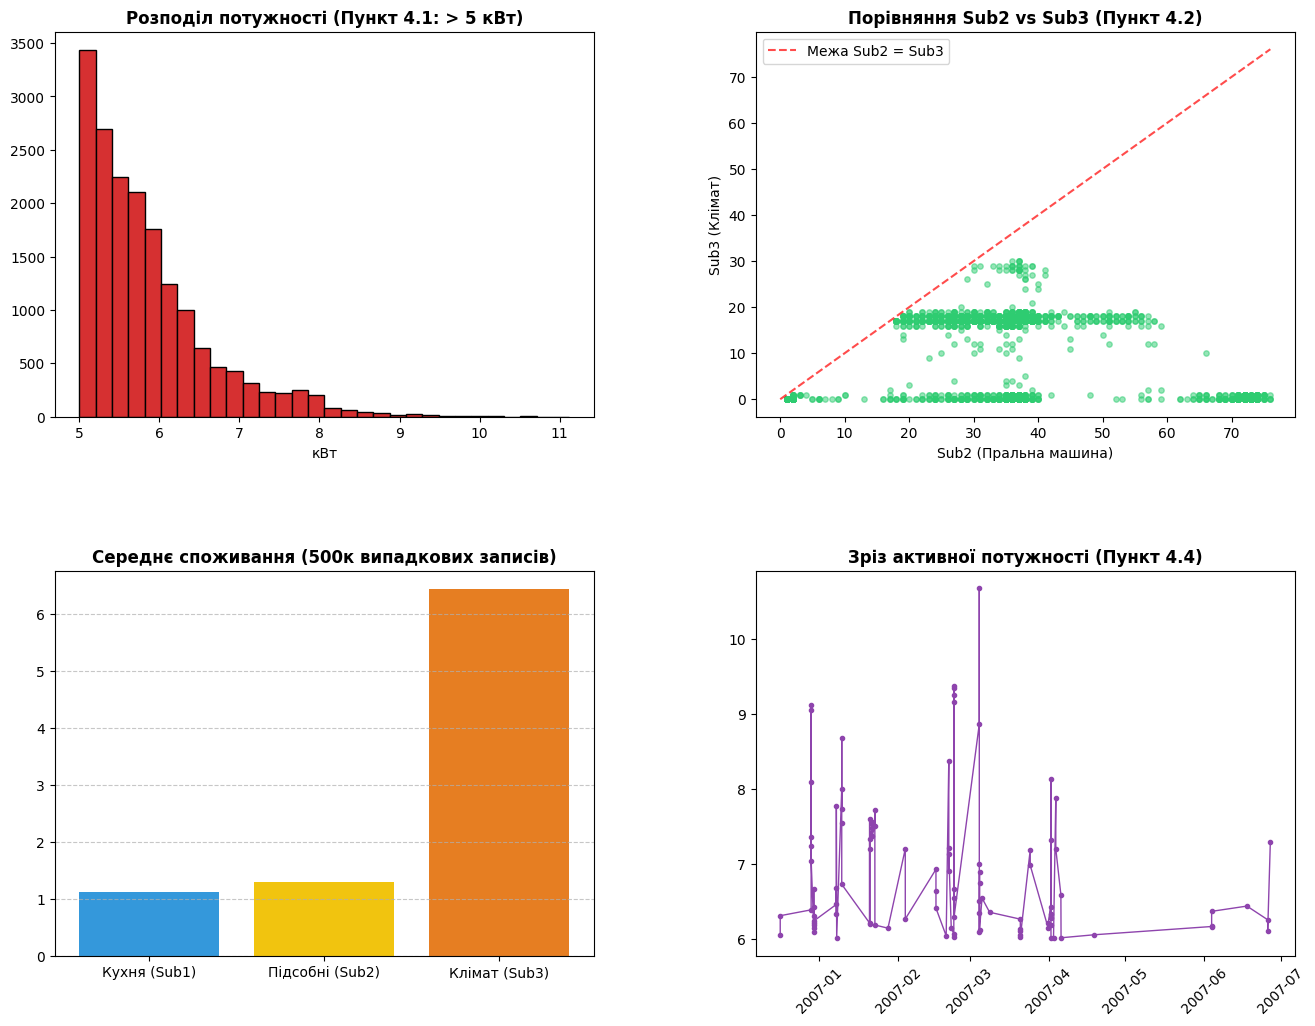

In [48]:
import matplotlib.pyplot as plt
import numpy as np


plt.style.use('seaborn-v0_8-muted')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)


axs[0, 0].hist(result_4_1['Global_active_power'], bins=30, color='#d63031', edgecolor='black')
axs[0, 0].set_title('Розподіл потужності (Пункт 4.1: > 5 кВт)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('кВт')


axs[0, 1].scatter(result_4_2['Sub_metering_2'], result_4_2['Sub_metering_3'], 
                  alpha=0.5, color='#2ecc71', s=15)

limit = max(result_4_2['Sub_metering_2'].max(), result_4_2['Sub_metering_3'].max())
axs[0, 1].plot([0, limit], [0, limit], color='red', linestyle='--', alpha=0.7, label='Межа Sub2 = Sub3')
axs[0, 1].set_title('Порівняння Sub2 vs Sub3 (Пункт 4.2)', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Sub2 (Пральна машина)')
axs[0, 1].set_ylabel('Sub3 (Клімат)')
axs[0, 1].legend()


labels = ['Кухня (Sub1)', 'Підсобні (Sub2)', 'Клімат (Sub3)']
axs[1, 0].bar(labels, result_4_3.values, color=['#3498db', '#f1c40f', '#e67e22'])
axs[1, 0].set_title('Середнє споживання (500к випадкових записів)', fontsize=12, fontweight='bold')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.7)


sample_data = result_4_4.iloc[:100] 
axs[1, 1].plot(sample_data.index, sample_data['Global_active_power'], 
               marker='.', linestyle='-', color='#8e44ad', linewidth=1)
axs[1, 1].set_title('Зріз активної потужності (Пункт 4.4)', fontsize=12, fontweight='bold')
axs[1, 1].tick_params(axis='x', rotation=45)

plt.show()

Виконання функцій та профілювання часу (timeit)

In [49]:

t1 = timeit.timeit(lambda: get_high_power(df_cleaned), number=1)
t2 = timeit.timeit(lambda: get_specific_intensity(df_cleaned), number=1)
t3 = timeit.timeit(lambda: get_random_means(df_cleaned), number=1)
t4 = timeit.timeit(lambda: get_complex_filter(df_cleaned), number=1)

print(f"Час виконання (Потужність > 5): {t1:.5f} сек")
print(f"Час виконання (Струм 19-20): {t2:.5f} сек")
print(f"Час виконання (Рандом 500к): {t3:.5f} сек")
print(f"Час виконання (Складний фільтр): {t4:.5f} сек")


result_complex = get_complex_filter(df_cleaned)
display(result_complex.head())


Час виконання (Потужність > 5): 0.00682 сек
Час виконання (Струм 19-20): 0.01655 сек
Час виконання (Рандом 500к): 0.14259 сек
Час виконання (Складний фільтр): 0.70642 сек


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 18:05:00,6.052,0.192,232.93,26.2,0.0,37.0,17.0
2006-12-16 18:08:00,6.308,0.116,232.25,27.0,0.0,36.0,17.0
2006-12-28 20:58:00,6.386,0.374,236.63,27.0,1.0,36.0,17.0
2006-12-28 21:02:00,8.088,0.262,235.50,34.4,1.0,72.0,17.0
2006-12-28 21:05:00,7.230,0.152,235.22,30.6,1.0,73.0,17.0


Нормалізація та стандартизація даних

In [50]:
cols_to_scale = ['Global_active_power', 'Global_intensity', 'Voltage']


df_norm = (df_cleaned[cols_to_scale] - df_cleaned[cols_to_scale].min()) / \
          (df_cleaned[cols_to_scale].max() - df_cleaned[cols_to_scale].min())


df_std = (df_cleaned[cols_to_scale] - df_cleaned[cols_to_scale].mean()) / \
         df_cleaned[cols_to_scale].std()

print("Нормалізовані дані:")
display(df_norm.head())

Нормалізовані дані:


,Global_active_power,Global_intensity,Voltage
dt,,,
2006-12-16 17:24:00,0.374796,0.377593,0.376090
2006-12-16 17:25:00,0.478363,0.473029,0.336995
2006-12-16 17:26:00,0.479631,0.473029,0.326010
2006-12-16 17:27:00,0.480898,0.473029,0.340549
2006-12-16 17:28:00,0.325005,0.323651,0.403231


Розрахунок коефіцієнтів кореляції


In [51]:
p_corr, _ = pearsonr(df_cleaned['Global_active_power'], df_cleaned['Global_intensity'])
s_corr, _ = spearmanr(df_cleaned['Global_active_power'], df_cleaned['Global_intensity'])

print(f"Коефіцієнт кореляції Пірсона: {p_corr:.4f}")
print(f"Коефіцієнт кореляції Спірмена: {s_corr:.4f}")

Коефіцієнт кореляції Пірсона: 0.9989
Коефіцієнт кореляції Спірмена: 0.9955


One Hot Encoding категоріального атрибута

In [52]:
df_cat = df_cleaned.copy()

df_cat['Day_Type'] = np.where(df_cat.index.dayofweek >= 5, 'Weekend', 'Weekday')


ohe_df = pd.get_dummies(df_cat['Day_Type'], prefix='Type')

print("Результат One Hot Encoding:")
display(ohe_df.head())

Результат One Hot Encoding:


,Type_Weekday,Type_Weekend
dt,,
2006-12-16 17:24:00,False,True
2006-12-16 17:25:00,False,True
2006-12-16 17:26:00,False,True
2006-12-16 17:27:00,False,True
2006-12-16 17:28:00,False,True


Фінальний етап: Аналіз часових витрат на виконання процедур


In [53]:

timing_results = {
    "Процедура": [
        "Фільтрація: Потужність > 5 кВт",
        "Фільтрація: Струм 19-20 А + споживання",
        "Вибірка 500,000 записів (середнє)",
        "Складний фільтр (час + зрізи)"
    ],
    "Час виконання (секунди)": [0.00713, 0.01824, 0.13923, 0.70997]
}


df_performance = pd.DataFrame(timing_results)

print("Зведені дані профілювання часу:")
display(df_performance)


print(f"\nНайшвидша операція: {df_performance.iloc[0]['Процедура']}")
print(f"Найбільш ресурсоємна операція: {df_performance.iloc[-1]['Процедура']}")

Зведені дані профілювання часу:


,Процедура,Час виконання (секунди)
0,Фільтрація: Потужність > 5 кВт,0.00713
1,Фільтрація: Струм 19-20 А + споживання,0.01824
2,"Вибірка 500,000 записів (середнє)",0.13923
3,Складний фільтр (час + зрізи),0.70997



Найшвидша операція: Фільтрація: Потужність > 5 кВт
Найбільш ресурсоємна операція: Складний фільтр (час + зрізи)
